In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
from darksirenpop.utilities.default_globals import *
from darksirenpop.utilities.priors import *
from darksirenpop.utilities.utils import *
from darksirenpop.utilities.redshift_utils import *
from darksirenpop.utilities.gw_selection_effects import *

import numpy as np
import pandas as pd
import healpy as hp
import torch
from tqdm import tqdm
import glob
import h5py
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt

from astropy.cosmology import LambdaCDM
from astropy.table import Table
from astropy.coordinates import SkyCoord

from scipy.integrate import romb
from scipy.spatial.distance import jensenshannon

from ligo.skymap.io.fits import read_sky_map
from ligo.skymap.postprocess import find_greedy_credible_levels
import bilby

make_nice_plots()


opening existing popsummary file: /home/lucas/Documents/PhD/gw_data/popsummary_files/gwtc5_updated_madau_dickinson_mmax_mass_TwoPeakBrokenPowerLawSmoothedMassDistribution_redshift_MadauDickinsonRedshift_magnitude_iid_spin_magnitude_gaussian_tilt_iid_spin_orientation_popsummary_result.h5


/home/lucas/Documents/PhD/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Specify paths

gwtc2p1_path = '/home/lucas/Documents/PhD/gw_data/PEsamples_gwtc2p1'
gwtc3p0_path = '/home/lucas/Documents/PhD/gw_data/PEsamples_gwtc3p0'
gwtc4p0_path = '/home/lucas/Documents/PhD/gw_data/PEsamples_gwtc4p0'
gwtc5p0_path = '/home/lucas/Documents/PhD/gw_data/PEsamples_gwtc5p0'
summary_csv_path = '/home/lucas/Documents/PhD/gw_data/events.csv'  # csv file downloaded from gwosc.org containing SNR and FAR for all events

PE_json_LVK_path = '/home/lucas/Documents/PhD/gw_data/reweighted-gwtc5/real_PEsamples_gwtc5.json'  # .json file that stores paths to PE samples published by LVK
PE_json_reweighted_path = '/home/lucas/Documents/PhD/gw_data/reweighted-gwtc5/real_PEsamples_reweight_gwtc5.json'  # .json file that stores paths to reweighted PE samples
masspop_summary_path = "/home/lucas/Documents/PhD/gw_data/popsummary_files/gwtc5_updated_madau_dickinson_mmax_mass_TwoPeakBrokenPowerLawSmoothedMassDistribution_redshift_MadauDickinsonRedshift_magnitude_iid_spin_magnitude_gaussian_tilt_iid_spin_orientation_popsummary_result.h5"

lvk_data_dir = "/home/lucas/Documents/PhD/gw_data"

reweighted_gw_data_dir = "/home/lucas/Documents/PhD/gw_data/reweighted-gwtc5"
reweighted_post_samps_dir = f'{reweighted_gw_data_dir}/samples'
reweighted_skymap_dir = f'{reweighted_gw_data_dir}/skymaps'
reweighted_skymaps_json = f'{reweighted_gw_data_dir}/real_skymaps_reweight_gwtc5.json'


# Filter data

In [3]:
# Get all available GW data

filenames_gwtc2p1 = glob.glob(gwtc2p1_path + '/*mixed_nocosmo.h5')
filenames_gwtc3p0 = glob.glob(gwtc3p0_path + '/*mixed_nocosmo.h5')
filenames_gwtc4p0 = glob.glob(gwtc4p0_path + '/*combined*.hdf5')
filenames_gwtc5p0 = glob.glob(gwtc5p0_path + '/*combined*.hdf5')
print(len(filenames_gwtc2p1), len(filenames_gwtc3p0), len(filenames_gwtc4p0), len(filenames_gwtc5p0))

all_filenames = filenames_gwtc2p1 + filenames_gwtc3p0 + filenames_gwtc4p0 + filenames_gwtc5p0
print(f'Got {len(all_filenames)} GWs with PE results, from which the NS candidates still have to be removed and SNR/FAR may still be insufficient.')

gwkeys = []
for fname in filenames_gwtc2p1 + filenames_gwtc3p0:
    gwkey = fname.split('-')[-1].split('_PED')[0]
    gwkeys.append(gwkey)
for fname in filenames_gwtc4p0 + filenames_gwtc5p0:
    gwkey = fname.split('-')[-2]
    gwkeys.append(gwkey)
print(gwkeys)


54 36 86 104
Got 280 GWs with PE results, from which the NS candidates still have to be removed and SNR/FAR may still be insufficient.
['GW190828_065509', 'GW190630_185205', 'GW170104_101158', 'GW190916_200658', 'GW190527_092055', 'GW190929_012149', 'GW190924_021846', 'GW190828_063405', 'GW190917_114630', 'GW151226_033853', 'GW190412_053044', 'GW151012_095443', 'GW190514_065416', 'GW170608_020116', 'GW190413_134308', 'GW190910_112807', 'GW190814_211039', 'GW190602_175927', 'GW190725_174728', 'GW190425_081805', 'GW190521_030229', 'GW190708_232457', 'GW170809_082821', 'GW190517_055101', 'GW190701_203306', 'GW190720_000836', 'GW190731_140936', 'GW190512_180714', 'GW190805_211137', 'GW190925_232845', 'GW190503_185404', 'GW190728_064510', 'GW190403_051519', 'GW190803_022701', 'GW190719_215514', 'GW190513_205428', 'GW190707_093326', 'GW150914_095045', 'GW190727_060333', 'GW190930_133541', 'GW190926_050336', 'GW190421_213856', 'GW190408_181802', 'GW190413_052954', 'GW190519_153544', 'GW190620

In [4]:
# Remove mergers possibly involving NSs

ns_candidates = ['GW190814_211039', 'GW230518_125908', 'GW230529_181500', 'GW170817', 'GW191219_163120', 'GW190425_081805', 'GW200115_042309', 'GW190917_114630', 'GW200210_092254', 'GW200105_162426']
ns_files = []
for file in all_filenames:
    for candidate in ns_candidates:
        if candidate in file:
            ns_files.append(file)
            gwkeys.remove(candidate)
            
all_filenames = [file for file in all_filenames if not file in ns_files]
print(f'Got {len(all_filenames)} GWs after removing NSs.')
print(f'Confirming removal of the GW names from list: {len(gwkeys)}')


Got 271 GWs after removing NSs.
Confirming removal of the GW names from list: 271


# Get SNR and FAR

In [5]:
# Collect SNR and FAR for all events, 

gwdat = pd.read_csv(summary_csv_path)

snr_dict = {}
snr_list = []
far_dict = {}
far_list = []
for key in gwkeys:

    snr = gwdat['network_matched_filter_snr'][gwdat['name'] == key].to_numpy()
    far = gwdat['far'][gwdat['name'] == key].to_numpy()

    if len(snr) == 0:
        print(f'Could not find key {key}')

        newkey = key.split('_')[0]

        snr_newkey = gwdat['network_matched_filter_snr'][gwdat['name'] == newkey].to_numpy()
        far_newkey = gwdat['far'][gwdat['name'] == newkey].to_numpy()
        print(f'But {newkey} got snr: {snr_newkey}')
        print(f'But {newkey} got far: {far_newkey}')
        
        if len(snr_newkey) == 0:
            print(f'WARNING: {key} and {newkey} not found! Skipping!')

        else:
            snr_dict[key] = snr_newkey
            snr_list.append(snr_newkey)

            far_dict[key] = far_newkey
            far_list.append(far_newkey)

    else:
        snr_dict[key] = snr
        snr_list.append(snr)
        print(key, 'snr', snr)

        far_dict[key] = far
        far_list.append(far)
        print(key, 'far', far)
    print()

print(f'Confirming length of SNR dict: {len(snr_dict.keys())}')
print(f'Confirming length of FAR dict: {len(far_dict.keys())}')


GW190828_065509 snr [10.2]
GW190828_065509 far [3.5e-05]

GW190630_185205 snr [16.4]
GW190630_185205 far [1.e-05]

Could not find key GW170104_101158
But GW170104 got snr: [13.8]
But GW170104 got far: [nan]

GW190916_200658 snr [8.1]
GW190916_200658 far [4.7]

GW190527_092055 snr [8.]
GW190527_092055 far [0.23]

GW190929_012149 snr [9.7]
GW190929_012149 far [0.16]

GW190924_021846 snr [12.]
GW190924_021846 far [1.e-05]

GW190828_063405 snr [16.5]
GW190828_063405 far [1.e-05]

Could not find key GW151226_033853
But GW151226 got snr: [12.7]
But GW151226 got far: [nan]

Could not find key GW190412_053044
But GW190412 got snr: [19.8]
But GW190412 got far: [1.e-05]

Could not find key GW151012_095443
But GW151012 got snr: [9.3]
But GW151012 got far: [nan]

GW190514_065416 snr [8.]
GW190514_065416 far [2.8]

Could not find key GW170608_020116
But GW170608 got snr: [15.3]
But GW170608 got far: [nan]

GW190413_134308 snr [10.6]
GW190413_134308 far [0.18]

GW190910_112807 snr [14.5]
GW190910_11

In [6]:
# Keep events that meet our threshold: SNR for O1/O2, FAR for O3/O4

far_thr = 1
snr_thr = 10

n = 0
below_thresh = []
for key in snr_dict.keys():
    run = get_run(key)
    
    if run in ['O3', 'O4']:
        if far_dict[key] > far_thr:
            below_thresh.append(key)
            continue
    elif run in ['O1', 'O2']:
        if snr_dict[key] < snr_thr:
            below_thresh.append(key)
            continue
    else:
        print('Huh?', key)
        
    n += 1

print(f'Got {n} GWs above our detection threshold.')
print(f'These {len(below_thresh)} events do not pass our threshold: {below_thresh}')


Got 256 GWs above our detection threshold.
These 15 events do not pass our threshold: ['GW190916_200658', 'GW151012_095443', 'GW190514_065416', 'GW190403_051519', 'GW190926_050336', 'GW190426_190642', 'GW191126_115259', 'GW200220_124850', 'GW191113_071753', 'GW191204_110529', 'GW200308_173609', 'GW200306_093714', 'GW200220_061928', 'GW200208_222617', 'GW200322_091133']


In [7]:
skip_these_files = []
for file in all_filenames:
    for key in below_thresh:
        if key in file:
            print(key, snr_dict[key], far_dict[key])
            skip_these_files.append(file)
            gwkeys.remove(key)

all_filenames = [file for file in all_filenames if not file in skip_these_files]
print(f'Got {len(all_filenames)} GWs after removing events below our detection threshold.')
print(f'Confirming length of key list: {len(gwkeys)}')


GW190916_200658 [8.1] [4.7]
GW151012_095443 [9.3] [nan]
GW190514_065416 [8.] [2.8]
GW190403_051519 [7.6] [7.7]
GW190926_050336 [8.1] [1.1]
GW190426_190642 [8.7] [4.1]
GW191126_115259 [8.3] [3.2]
GW200220_124850 [8.5] [30.]
GW191113_071753 [7.9] [26.]
GW191204_110529 [8.9] [3.3]
GW200308_173609 [4.7] [2.4]
GW200306_093714 [7.8] [24.]
GW200220_061928 [7.2] [6.8]
GW200208_222617 [7.4] [4.8]
GW200322_091133 [4.5] [140.]
Got 256 GWs after removing events below our detection threshold.
Confirming length of key list: 256


In [8]:
# Write PE samples paths to .json file
PEdict = {}
for key, fname in zip(gwkeys, all_filenames):
    if key not in fname:
        print(key, fname)
    
    PEdict[key] = fname

with open(PE_json_LVK_path, 'w') as outfile:
    json.dump(PEdict, outfile)


# Check for PE priors hdf5 files

In [9]:
# Examples of waveform approximants: 'C00:Mixed', 'C01:Mixed', 'C00:IMRPhenomXO4a', 'C00:IMRPhenomXPHM-SpinTaylor', 'C00:NRSur7dq4',

with open(PE_json_LVK_path, "r") as f:
    PEpaths = json.load(f)

approxdict = {}
nopriors = []
no_dlpriors = []
for key in PEpaths.keys():
    path = PEpaths[key]

    # if key not in ['GW190924_021846']:
    #     continue

    with h5py.File(path, 'r') as f:

        got_priors = False
        apx = []
        for approximant in list(f.keys()):
            if approximant in ['history', 'version']:
                continue
            
            try:
                prior = f[approximant]['priors']
                got_priors = True
                apx.append(approximant)
            except KeyError:
                continue
        
        if not got_priors:
            nopriors.append((key))
            continue
        
        got_dlprior = False
        apx_with_dlprior = []
        for approximant in apx:
            prior = f[approximant]['priors']
            try:
                analytic_prior = prior['analytic']['luminosity_distance']
                got_dlprior = True
                apx_with_dlprior.append(approximant)
                
                print(list(analytic_prior))
                
            except KeyError:
                continue
        
        print(f'{key} has dL prior for: {apx_with_dlprior}')
        print()

        approxdict[key] = apx_with_dlprior
        
        if not got_dlprior:
            no_dlpriors.append(key)

print(f'Summary: no priors at all for {nopriors}. \nNo dLpriors for {no_dlpriors}.')


[np.bytes_(b"PowerLaw(alpha=2, minimum=10, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")]
GW190828_065509 has dL prior for: ['C01:IMRPhenomXPHM']

[np.bytes_(b"PowerLaw(alpha=2, minimum=100, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")]
GW190630_185205 has dL prior for: ['C01:IMRPhenomXPHM']

[np.bytes_(b"PowerLaw(alpha=2, minimum=100, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")]
GW170104_101158 has dL prior for: ['C01:IMRPhenomXPHM']

[np.bytes_(b"PowerLaw(alpha=2, minimum=100, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")]
GW190527_092055 has dL prior for: ['C01:IMRPhenomXPHM']

[np.bytes_(b"PowerLaw(alpha=2, minimum=100, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")]
GW190929_012149 has dL prior for: ['C01:IMRPhenomXPHM']

GW190924_021846 has dL pri

In [10]:
# Check that IMRPhenomXPHM waveform approximant is present for all events

a = 'C00:IMRPhenomXPHM-SpinTaylor'
b = 'C01:IMRPhenomXPHM'
c = 'C01:IMRPhenomXPHM-SpinTaylor'
for key in approxdict.keys():
    if len(approxdict[key]) == 1:
        if b not in approxdict[key]:
            print(key, approxdict[key])
    if len(approxdict[key]) > 1:
        if (a not in approxdict[key]) and (c not in approxdict[key]):
            print(key, approxdict[key])


In [11]:
# Store approximants and PEpriors in dictionary

prior_dict = {}
for i, key in enumerate(PEpaths.keys()):
    path = PEpaths[key]

    ### Checked manually: dl^2 prior with 'C01:IMRPhenomXPHM' waveform should be fine for all events missing analytical PE prior. ###
    if key in no_dlpriors:
        with h5py.File(PEpaths['GW190828_065509'], 'r') as f:
            prior = list(f['C01:IMRPhenomXPHM']['priors']['analytic']['luminosity_distance'])
        prior_dict[key] = ('C01:IMRPhenomXPHM', prior)
    #################################################################################################################################
    
    else:
        with h5py.File(path, 'r') as f:
            try:
                prior = list(f['C01:IMRPhenomXPHM']['priors']['analytic']['luminosity_distance'])
                prior_dict[key] = ('C01:IMRPhenomXPHM', prior)
            except:
                try:
                    prior = list(f['C01:IMRPhenomXPHM-SpinTaylor']['priors']['analytic']['luminosity_distance'])
                    prior_dict[key] = ('C01:IMRPhenomXPHM-SpinTaylor', prior)
                except:
                    prior = list(f['C00:IMRPhenomXPHM-SpinTaylor']['priors']['analytic']['luminosity_distance'])
                    prior_dict[key] = ('C00:IMRPhenomXPHM-SpinTaylor', prior)

    print(prior_dict[key][1], key)


[np.bytes_(b"PowerLaw(alpha=2, minimum=10, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")] GW190828_065509
[np.bytes_(b"PowerLaw(alpha=2, minimum=100, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")] GW190630_185205
[np.bytes_(b"PowerLaw(alpha=2, minimum=100, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")] GW170104_101158
[np.bytes_(b"PowerLaw(alpha=2, minimum=100, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")] GW190527_092055
[np.bytes_(b"PowerLaw(alpha=2, minimum=100, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")] GW190929_012149
[np.bytes_(b"PowerLaw(alpha=2, minimum=10, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")] GW190924_021846
[np.bytes_(b"PowerLaw(alpha=2, minimum=10, maximum=10000, name='luminosity_dis

# Reweight individual GW redshift posteriors
## We want to use a uniform-in-comoving-volume PE prior + an astrophysical mass prior

#### First check the hyperparameters posteriors. We take the MAP values of the madau_dickinson redshift model (which is consistent with, but not equal to their default model) and broken PL + 2P mass model. We ignore other parameters such as spin (I know, be nice.)

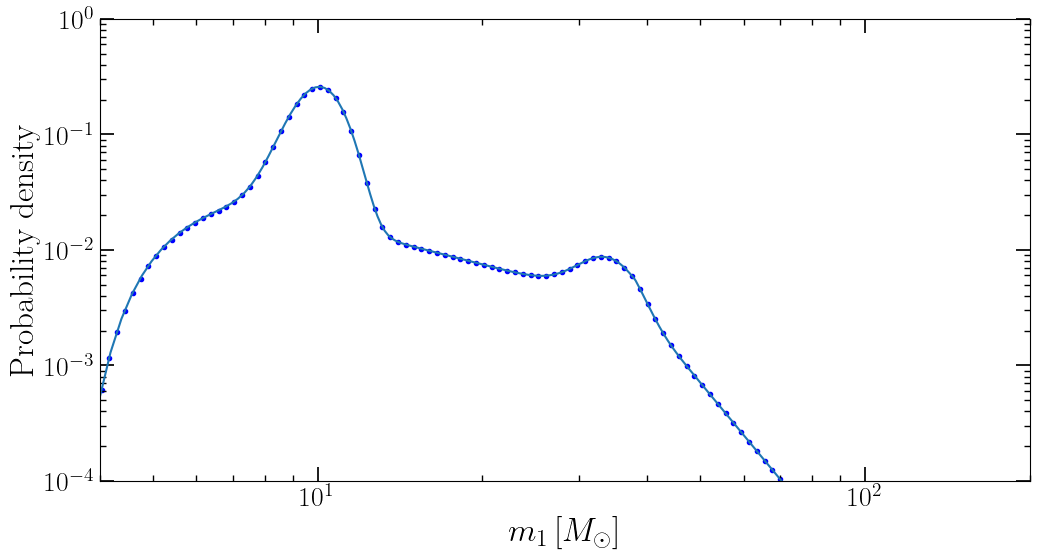

In [12]:
# Plot our mass prior

# The Prior object is already important from gw_selection_effects.py\
# Note that you can get the plots in the LVK papers by multiplying the marginal prob. with the rate, also done in gw_selection_effects.py. Also,
# this requires taking all hyperparameter samples, constructing the Prior for each set, and taking the median at each m_1.

fig, ax = plt.subplots(figsize=(12,6))
marr = torch.as_tensor(np.linspace(3, 200, 1000))
ax.plot(marr, masspop_MAP.mdis['mass_1'].prob(marr))

N = 128+1
m1 = np.geomspace(3, 200, N)
for m1_val in m1:
    m2 = np.linspace(3, m1_val, N)
    masspop_eval = masspop_MAP.joint_prob(np.full_like(m2, m1_val), m2).detach().cpu().numpy()
    m1_marginalprob = romb(masspop_eval, dx=np.diff(m2)[0])
    ax.scatter(m1_val, m1_marginalprob, marker='.', color='blue')
ax.loglog()
ax.set_xlim(4e0, 2e2)
ax.set_ylim(1e-4, 1e0)
ax.set_xlabel(r'$m_{1} \, [M_{\odot}]$')
ax.set_ylabel('Probability density')
plt.show()


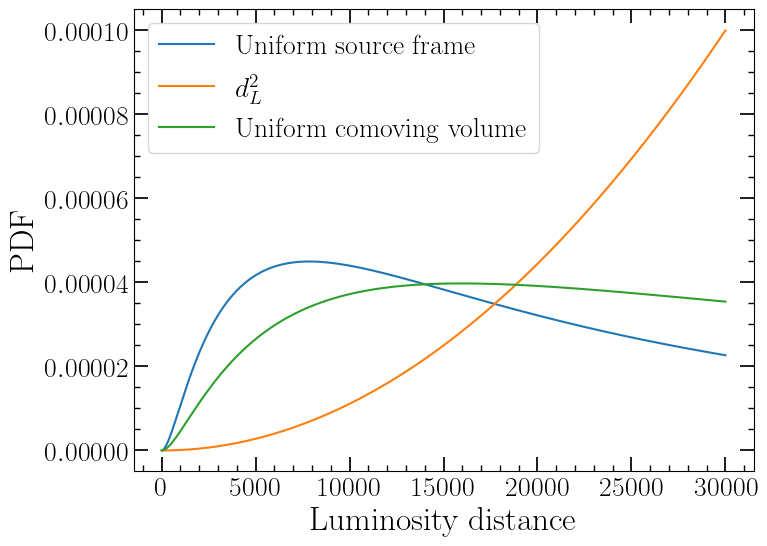

In [13]:
# Compare distance priors

unif_volume_PEprior = bilby.gw.prior.PowerLaw(alpha=2, minimum=10, maximum=30000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)
unif_comoving_volume_PEprior = bilby.gw.prior.UniformComovingVolume(minimum=10.0, maximum=30000, cosmology=LambdaCDM(name=None, H0=67.9, Om0=0.3065, Ode0=0.6935, Tcmb0=0., Neff=3.04, m_nu=None, Ob0=None), name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)
unif_source_frame_PEprior = bilby.gw.prior.UniformSourceFrame(minimum=10.0, maximum=30000, cosmology=LambdaCDM(name=None, H0=67.9, Om0=0.3065, Ode0=0.6935, Tcmb0=0., Neff=3.04, m_nu=None, Ob0=None), name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)

dd = np.linspace(10, 30000, 1024+1)
zz = fast_z_at_value(COSMO.luminosity_distance, dd * u.Mpc)
plt.figure(figsize=(8,6))
plt.plot(dd, unif_source_frame_PEprior.prob(dd), label='Uniform source frame')
plt.plot(dd, unif_volume_PEprior.prob(dd), label=r'$d_L^2$')
plt.plot(dd, unif_comoving_volume_PEprior.prob(dd), label='Uniform comoving volume')
plt.legend()
plt.xlabel('Luminosity distance')
plt.ylabel('PDF')
plt.show()


In [14]:
# Functions for reweighting the posterior samples by importance resampling

namespace = {
    "bilby": bilby,
    "PowerLaw": bilby.gw.prior.PowerLaw,
    "LambdaCDM": LambdaCDM,
}

def prior_from_bytes(x):
    s = x.decode() if isinstance(x, bytes) else str(x)
    return eval(s, {"__builtins__": {}}, namespace)


def jacobian(z):
    dl = COSMO.luminosity_distance(z).value
    H_z = COSMO.H(z).value
    return (1 + z)**2 * ddl_dz(dl, z, H_z)


def get_z_m1_m2_PEprior_sourceframe(prior, dl_samps, z_samps):
    PEprior_detframe = prior.prob(dl_samps)  # pi_PE(dl, m1d, m2d)
    PEprior_sourceframe = PEprior_detframe * jacobian(z_samps)  # pi_PE(z, m1s, m2s) = pi_PE(dl, m1d, m2d) |ddl/dz * dm1d/dm1s * dm2d/dm2s| = pi_PE(dl, m1d, m2d) * (1 + z)**2 * |ddl/dz|
    return PEprior_sourceframe


def reweight_samps(samps, weights, size):
    '''
    Importance resampling of array ``samps``, weighted with ``weights``.
    Draws ``size`` samples.
    Checks the effective number of samples, and gives a warning of 
    this is less than 10% of the original sample size.
    '''
    w = weights / np.sum(weights)
    neff = 1.0 / np.sum(w**2)
    if neff < 0.1 * len(samps):
        print(f"WARNING: effective sample size is only {neff:.0f}/{len(samps)} ({neff/len(samps):.1%})")
    idx = np.random.choice(len(samps), p=w, size=size, replace=True)
    return samps[idx], idx


def get_reweighted_z_samples(posterior_samples, prior, target_prior, masspop=masspop_MAP, size=5000):
    dl_samps = posterior_samples['luminosity_distance']
    z_samps = posterior_samples['redshift']
    m1s_samps = posterior_samples['mass_1_source']
    m2s_samps = posterior_samples['mass_2_source']

    PEprior_sourceframe = get_z_m1_m2_PEprior_sourceframe(prior, dl_samps, z_samps)
    target_PEprior_sourceframe = get_z_m1_m2_PEprior_sourceframe(target_prior, dl_samps, z_samps)

    z_samps_dlprior_reweight, _ = reweight_samps(z_samps, weights = target_PEprior_sourceframe / PEprior_sourceframe, size=size)
    z_samps_full_reweight, full_reweight_idx = reweight_samps(z_samps, weights = masspop.joint_prob(m1s_samps, m2s_samps).detach().cpu().numpy() * target_PEprior_sourceframe / PEprior_sourceframe, size=size)

    return z_samps, z_samps_dlprior_reweight, z_samps_full_reweight, full_reweight_idx


def js_distance(samples1, samples2, bins=100):
    lo = min(np.min(samples1), np.min(samples2))
    hi = max(np.max(samples1), np.max(samples2))

    p, _ = np.histogram(samples1, bins=bins, range=(lo, hi), density=True)
    q, _ = np.histogram(samples2, bins=bins, range=(lo, hi), density=True)

    # normalize
    p = p / p.sum()
    q = q / q.sum()

    return jensenshannon(p, q)


In [15]:
NSAMPS = int(1e4)

with open(PE_json_LVK_path, "r") as f:
    PEpaths = json.load(f)

target_prior = unif_comoving_volume_PEprior
for key in tqdm(prior_dict.keys()):

    run = get_run(key)

    approximant, prior = prior_dict[key]
    prior = prior_from_bytes(prior[0])

    path = PEpaths[key]
    
    with h5py.File(path, 'r') as f:
        posterior_samples = f[approximant]['posterior_samples']
        z_samps, z_samps_dlprior_reweight, z_samps_full_reweight, full_reweight_idx = get_reweighted_z_samples(posterior_samples, prior, target_prior=target_prior, masspop=masspop_MAP, size=NSAMPS)

        has_mixed = False
        try:
            posterior_samples = f['C01:Mixed']['posterior_samples']
            z_samps_mixed, z_samps_dlprior_reweight_mixed, z_samps_full_reweight_mixed, full_reweight_idx = get_reweighted_z_samples(posterior_samples, prior, target_prior=target_prior, masspop=masspop_MAP, size=NSAMPS)
            dl_samps_full_reweight_mixed = COSMO.luminosity_distance(z_samps_full_reweight_mixed).value
            has_mixed = True
        except Exception as e:
            try:
                posterior_samples = f['C00:Mixed']['posterior_samples']
                z_samps_mixed, z_samps_dlprior_reweight_mixed, z_samps_full_reweight_mixed, full_reweight_idx = get_reweighted_z_samples(posterior_samples, prior, target_prior=target_prior, masspop=masspop_MAP, size=NSAMPS)
                dl_samps_full_reweight_mixed = COSMO.luminosity_distance(z_samps_full_reweight_mixed).value
                has_mixed = True
            except Exception as e:
                print(f'No mixed samples for {key}')

        # I want to know if the mixed samples give different results from the IMRPhenomXPHM samples, without checking everything by eye.
        # We calculate the JS distance and plot a histogram comparing the posteriors if this distance is larger than 0.15.
        if has_mixed:  
            d = js_distance(z_samps_full_reweight, z_samps_full_reweight_mixed)
            if d > 0.15:
                print(f'JS divergence: {d}')
                
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
                plt.suptitle(f'{key}', fontsize=30)
                if has_mixed:
                    ax1.hist(dl_samps_full_reweight_mixed, density=True, bins=100, histtype='step', linewidth=1, label='Mixed reweight', color='black', zorder=10)
                    ax2.hist(z_samps_full_reweight_mixed, density=True, bins=100, histtype='step', linewidth=1, color='black', zorder=10)

                ax1.hist(COSMO.luminosity_distance(z_samps).value, density=True, bins=100, histtype='step', linewidth=3, label='Initial')
                ax1.hist(COSMO.luminosity_distance(z_samps_dlprior_reweight).value, density=True, bins=100, histtype='step', linewidth=3, label=r'Reweighted to target dl prior')
                ax1.hist(COSMO.luminosity_distance(z_samps_full_reweight).value, density=True, bins=100, histtype='step', linewidth=3, label=r'Also weighted by $p_{\rm pop}(m_1^s, m_2^s)$')
                ax1.legend()
                ax1.set_xlabel('Luminosity distance [Mpc]')
                ax1.set_ylabel('Probability density')

                ax2.hist(z_samps, density=True, bins=100, histtype='step', linewidth=3, label='Old Posterior')
                ax2.hist(z_samps_dlprior_reweight, density=True, bins=100, histtype='step', linewidth=3)
                ax2.hist(z_samps_full_reweight, density=True, bins=100, histtype='step', linewidth=3)
                ax2.set_xlabel('Redshift')
                ax2.set_ylabel('Probability density')
                plt.show()

    break  # Comment if you don't want to skip this cell


  0%|          | 0/256 [00:02<?, ?it/s]


# Checks and verifications are done. Reweight, and write samples to hdf5.

In [16]:
def write_posterior_to_hdf5(filename, idx, posterior_samples, approximant):
     
    phi_samples = posterior_samples['ra'][idx]
    dec_samples = posterior_samples['dec'][idx]
    rlum_samples = posterior_samples['luminosity_distance'][idx]
    rcom_samples = posterior_samples['comoving_distance'][idx]
    redshift_samples = posterior_samples['redshift'][idx]

    mass_1_source_samples = posterior_samples['mass_1_source'][idx]
    mass_2_source_samples = posterior_samples['mass_2_source'][idx]
    mass_ratio_samples = posterior_samples['mass_ratio'][idx]
    chi_eff = posterior_samples['chi_eff'][idx]

    samples_table = Table([phi_samples, dec_samples, rlum_samples, rcom_samples, redshift_samples, 
                           mass_1_source_samples, mass_2_source_samples, mass_ratio_samples, chi_eff], 
                        names=('ra', 'dec', 'luminosity_distance', 'comoving_distance', 'redshift',
                               'mass_1_source', 'mass_2_source', 'mass_ratio', 'chi_eff'))
    
    with h5py.File(filename, "w") as f:
        mock_group = f.require_group(approximant)
        mock_group.create_dataset('posterior_samples', data=samples_table)

    return


nsamps = int(1e4)

target_prior = unif_comoving_volume_PEprior
for key in tqdm(prior_dict.keys()):
    approximant, prior = prior_dict[key]
    prior = prior_from_bytes(prior[0])
    path = PEpaths[key]
    with h5py.File(path, 'r') as f:
        posterior_samples = f[approximant]['posterior_samples']
        _, _, _, full_reweight_idx = get_reweighted_z_samples(posterior_samples, prior, target_prior=target_prior, masspop=masspop_MAP, size=nsamps)

        filename = os.path.join(reweighted_post_samps_dir, f"{key}.h5")
        # write_posterior_to_hdf5(filename, full_reweight_idx, posterior_samples, approximant)  # Uncomment if you want to store the files
        
        break  # Comment if you don't want to skip this cell

# Worst effective sample size is 8.0%. Fine by me!


  0%|          | 0/256 [00:01<?, ?it/s]


In [17]:
# Write reweighted PE samples paths to .json file

reweight_PEdict = {}
for key in tqdm(prior_dict.keys()):
    filename = os.path.join(reweighted_post_samps_dir, f"{key}.h5")
    reweight_PEdict[key] = filename
    
with open(PE_json_reweighted_path, 'w') as outfile:
    json.dump(reweight_PEdict, outfile)


100%|██████████| 256/256 [00:00<00:00, 2227680.13it/s]


# Get merger properties from new samples

In [18]:
with open(PE_json_reweighted_path, "r") as f:
    gw_path_dict = json.load(f)
gw_keys = list(gw_path_dict.keys())

redshift_dict = {}
redshift_list = []
mass_dict = {}
mass_list = []
lumdist_dict = {}
lumdist_list = []
for key in gw_keys:
    filename = gw_path_dict[key]
    approx, _ = prior_dict[key]
    
    with h5py.File(filename, 'r') as PEsamples:
        data = PEsamples[approx]

        z = data['posterior_samples']['redshift']
        redshift = np.median(z)
        redshift_lower = np.quantile(z, 0.16) - redshift
        redshift_upper = np.quantile(z, 0.84) - redshift
        del z

        m = data['posterior_samples']['mass_1_source']
        primary_mass = np.median(m)
        primary_mass_lower = np.quantile(m, 0.16) - primary_mass
        primary_mass_upper = np.quantile(m, 0.84) - primary_mass
        del m

        d_l = data['posterior_samples']['luminosity_distance']
        lumdist = np.median(d_l)
        lumdist_lower = np.quantile(d_l, 0.16) - lumdist
        lumdist_upper = np.quantile(d_l, 0.84) - lumdist
        del d_l

        dat = np.array([redshift, redshift_upper, redshift_lower])
        redshift_dict[key] = dat
        redshift_list.append(redshift)
        print(key, 'redshift', redshift_dict[key])

        dat = np.array([primary_mass, primary_mass_upper, primary_mass_lower])
        mass_dict[key] = dat
        mass_list.append(primary_mass)
        print(key, 'primary mass', mass_dict[key])

        dat = np.array([lumdist, lumdist_upper, lumdist_lower])
        lumdist_dict[key] = dat
        lumdist_list.append(lumdist)
        print(key, 'luminosity distance', lumdist_dict[key])


GW190828_065509 redshift [ 0.30332496  0.07022725 -0.07327242]
GW190828_065509 primary mass [21.78557956  4.41414935 -4.36468398]
GW190828_065509 luminosity distance [1618.91594894  443.59280157 -437.84873359]
GW190630_185205 redshift [ 0.16881091  0.06478128 -0.04220389]
GW190630_185205 primary mass [33.30636289  3.31003555 -2.62684855]
GW190630_185205 luminosity distance [ 836.41515419  365.18242031 -225.37970748]
GW170104_101158 redshift [ 0.21421091  0.04288833 -0.05324162]
GW170104_101158 primary mass [29.14497696  3.47988681 -3.1635069 ]
GW170104_101158 luminosity distance [1089.98598336  249.58575647 -296.21690645]
GW190527_092055 redshift [ 0.48567704  0.16229023 -0.13959287]
GW190527_092055 primary mass [33.04314444  4.35820831 -4.2128427 ]
GW190527_092055 luminosity distance [2814.39890387 1170.69398048 -928.04951969]
GW190929_012149 redshift [ 0.77996313  0.26896506 -0.2395912 ]
GW190929_012149 primary mass [ 50.31002121  11.8754925  -10.74539447]
GW190929_012149 luminosity 

In [19]:
# Get relative luminosity distance errors

relerr = []
for key in reweight_PEdict.keys():

    approximant, prior = prior_dict[key]
    prior = prior_from_bytes(prior[0])

    path = reweight_PEdict[key]
    
    with h5py.File(path, 'r') as f:
        posterior_samples = f[approximant]['posterior_samples']

        z = posterior_samples['redshift']

        x = COSMO.luminosity_distance(z).value
        x16, x50, x84 = np.quantile(x, [0.16, 0.50, 0.84])

        dL_relerr = (x84 - x16) / 2 / x50 
        relerr.append(dL_relerr)

print(f'{np.quantile(relerr, 0.5):.2f}, -{np.quantile(relerr, 0.5) - np.quantile(relerr, 0.05):.2f}, +{np.quantile(relerr, 0.95) - np.quantile(relerr, 0.5):.2f}')


0.28, -0.11, +0.09


# Now generate skymaps from these samples using $\texttt{ligo-skymap-from-samples}$.
# We go on to inspect the skymaps before and after reweighting

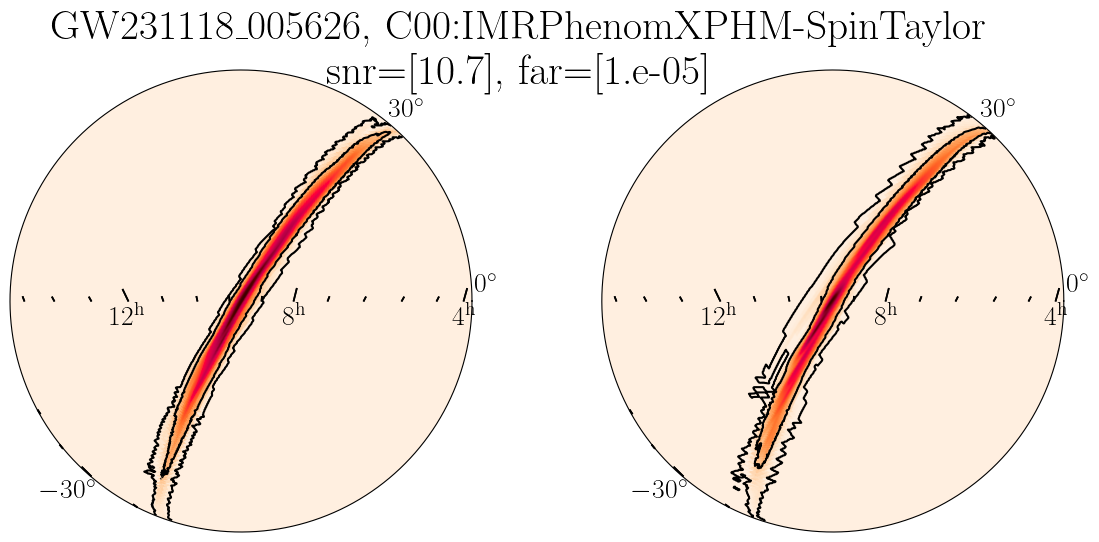

In [20]:
BASE = Path(lvk_data_dir)

def get_lvk_skymap(gwname, approximant):

    if approximant == "C00:IMRPhenomXPHM-SpinTaylor":
        apx_name = "IMRPhenomXPHM_SpinTaylor"
    else:
        apx_name = approximant.split(":")[-1]
    paths = [
        BASE / f"gwtc5/IGWN-GWTC5p0-29ebe06b7_25-Archived_Skymaps/parameter_estimation/skymaps/IGWN-GWTC5p0-29ebe06b7_25-{gwname}-{apx_name}_Skymap_PEDataRelease.fits.gz",
        BASE / f"IGWN-GWTC4p0-1a206db3d_721-Archived_Skymaps/IGWN-GWTC4p0-1a206db3d_721-{gwname}-{apx_name}_Skymap_PEDataRelease.fits.gz",
        BASE / f"IGWN-GWTC3p0-v2-PESkyLocalizations/IGWN-GWTC3p0-v2-{gwname}_PEDataRelease_cosmo_reweight_{approximant}.fits",
        BASE / f"IGWN-GWTC2p1-v2-PESkyMaps/IGWN-GWTC2p1-v2-{gwname}_PEDataRelease_cosmo_reweight_{approximant}.fits"
    ]

    errors = []
    for path in paths:
        try:
            return read_sky_map(path)
        except Exception as e:
            errors.append(f"{path}: {e}")
    raise FileNotFoundError(
        f"Could not find skymap for {gwname=} {approximant=}\n"
        + "\n".join(errors)
    )

for key in prior_dict.keys():
    # if key != 'GW231123_135430':
    #     continue

    run = get_run(key)
    if run != 'O4':
        continue

    apx, prior = prior_dict[key]

    try:
        map_path = f'{reweighted_skymap_dir}/{key}.fits.gz'
        prob, _ = read_sky_map(map_path)
    except:
        continue
        
    cls = find_greedy_credible_levels(prob)

    ipix_max = np.argmax(prob)
    nside = hp.npix2nside(len(prob))
    theta, phi = hp.pix2ang(nside, ipix_max)
    ra = np.degrees(phi)
    dec = 90 - np.degrees(theta)

    center = SkyCoord(ra, dec, unit="deg")

    prob_lvk, _ = get_lvk_skymap(key, apx)
    cls_lvk = find_greedy_credible_levels(prob_lvk)

    fig, axs = plt.subplots(
        1, 2,
        figsize=(14, 6),
        subplot_kw={
            "projection": "astro globe",
            "center": center,
        },
    )

    axs[0].contour_hpx(
        cls,
        levels=[0.9, 0.999],
        colors="black",
        linewidths=1.5,
    )
    
    axs[0].imshow_hpx(prob, cmap='cylon')

    axs[1].contour_hpx(
        cls_lvk,
        levels=[0.9, 0.999],
        colors="black",
        linewidths=1.5,
    )
    
    axs[1].imshow_hpx(prob_lvk, cmap='cylon')

    plt.suptitle(f'{key}, {apx}\nsnr={snr_dict[key]}, far={far_dict[key]}', fontsize=30)
    plt.show()
    
    break  # Comment if you don't want to skip this cell


In [21]:
# Write new skymap paths to .json file
skymap_dict = {}
for file in glob.glob(f'{reweighted_skymap_dir}/*.fits.gz'):
    gwname = file.split('/')[-1].split('.')[0]
    skymap_dict[gwname] = file
print(len(skymap_dict.keys()), skymap_dict.keys())

with open(reweighted_skymaps_json, 'w') as outfile:
    json.dump(skymap_dict, outfile)


256 dict_keys(['GW230706_104333', 'GW230825_041334', 'GW191222_033537', 'GW190731_140936', 'GW190725_174728', 'GW240530_012417', 'GW231108_125142', 'GW240519_012815', 'GW240622_004008', 'GW250118_055802', 'GW230806_204041', 'GW231231_154016', 'GW230723_101834', 'GW240501_033534', 'GW230824_033047', 'GW240612_081540', 'GW241114_235258', 'GW241109_033317', 'GW231001_140220', 'GW241111_111552', 'GW240830_211120', 'GW240915_001357', 'GW230814_230901', 'GW241130_110422', 'GW231005_021030', 'GW190412_053044', 'GW230924_124453', 'GW241210_060606', 'GW231206_233134', 'GW231114_043211', 'GW240420_175625', 'GW200208_130117', 'GW230814_061920', 'GW190517_055101', 'GW170809_082821', 'GW240505_133552', 'GW190727_060333', 'GW230820_212515', 'GW240615_160735', 'GW250109_010541', 'GW241130_034908', 'GW231113_200417', 'GW230920_071124', 'GW230624_113103', 'GW230726_002940', 'GW240618_071627', 'GW250118_023225', 'GW190828_063405', 'GW231129_081745', 'GW241102_144729', 'GW230712_090405', 'GW200225_060421